In [ ]:
import pandas as pd

In [ ]:
df =pd.read_csv("maisons_taiwan.csv")

In [ ]:
print(df.head())

       date   age      metro  epicerie  latitude  longitude  prix
0  2012.917  32.0   84.87882        10  24.98298  121.54024  37.9
1  2012.917  19.5  306.59470         9  24.98034  121.53951  42.2
2  2013.583  13.3  561.98450         5  24.98746  121.54391  47.3
3  2013.500  13.3  561.98450         5  24.98746  121.54391  54.8
4  2012.833   5.0  390.56840         5  24.97937  121.54245  43.1


In [15]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       414 non-null    float64
 1   age        414 non-null    float64
 2   metro      414 non-null    float64
 3   epicerie   414 non-null    int64  
 4   latitude   414 non-null    float64
 5   longitude  414 non-null    float64
 6   prix       414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [16]:
df.describe()

,date,age,metro,epicerie,latitude,longitude,prix
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


In [17]:
import numpy as np
import matplotlib.pyplot as plt


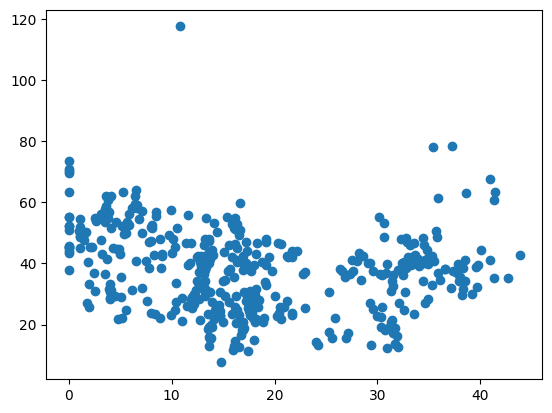

In [19]:
plt.scatter(df['age'],df['prix'])

In [71]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score


In [28]:
X=df[["age"]]
y=df["prix"]

In [29]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [31]:
model.coef_

array([-0.25978378])

In [32]:
model.intercept_

np.float64(42.88289629775735)

In [34]:
y_pred=model.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

12.853214192676935


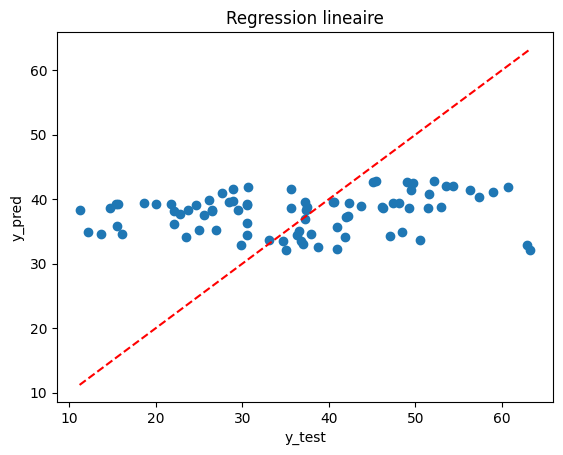

In [49]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.title("Regression lineaire")
plt.show()

# Régression multiple


In [50]:
X=df[["age","metro","epicerie"]]
y=df["prix"]

In [51]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [52]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [53]:
model.coef_

array([-0.25840543, -0.00549834,  1.24734248])

In [54]:
# y= -0.25age- 0.005metro+ 1.24epicerie +45

In [55]:
y_pred=model.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print(rmse)

7.673868078735505


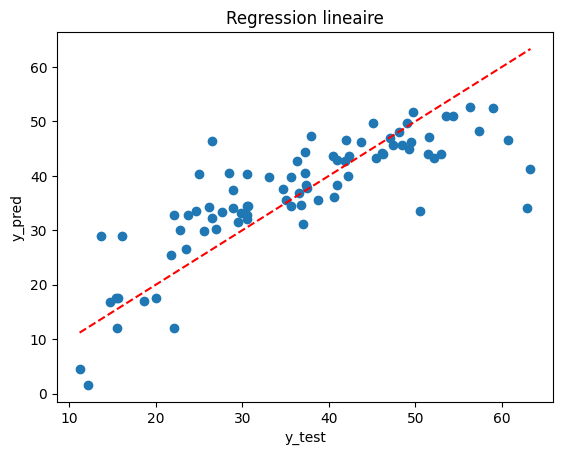

In [56]:
plt.scatter(y_test,y_pred)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.title("Regression lineaire")
plt.show()

In [57]:
from sklearn.preprocessing import PolynomialFeatures

In [65]:
poly=PolynomialFeatures(degree=2,include_bias=False)

In [73]:
X_poly=poly.fit_transform(X)

In [74]:
X_train_poly,X_test_poly,y_train_poly,y_test_poly=train_test_split(xpoly,y,test_size=0.2,random_state=42)

In [69]:
model_poly=LinearRegression()
model_poly.fit(X_train_poly,y_train_poly)

LinearRegression()

In [79]:
y_pred_poly=model_poly.predict(X_test_poly)
rmse_poly=np.sqrt(mean_squared_error(y_test_poly,y_pred_poly))
r2__poly=r2_score(y_test_poly,y_pred_poly)
print(rmse_poly)
print(r2__poly)

6.918172917454514
0.7147044026999936


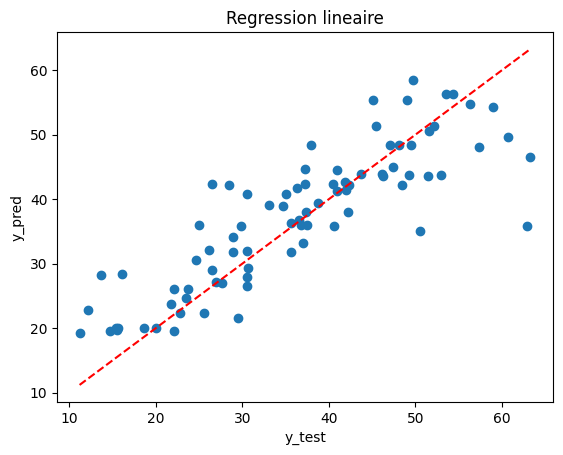

In [76]:
plt.scatter(y_test,y_pred_poly)
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],"r--")
plt.xlabel("y_test")
plt.ylabel("y_pred")
plt.title("Regression lineaire")
plt.show()